# 02 Feature Selection: Transfer-Oriented Feature Sets

This redesigned notebook creates two feature sets:

1. `vif`: correlation screening + VIF screening for an interpretable baseline.
2. `tree`: correlation screening only, intended for tree-based models and Taiwan transfer.

The transfer-oriented pipeline drops truly non-transferable US encodings but keeps policy and energy-economic concepts for later Taiwan mapping.

## Setup

In [1]:
import sys
sys.path.append('../')

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import (
    load_data, set_seed, compute_vif, remove_high_corr_features,
    label_potential, prepare_features, get_target_cols,
    get_non_transferable_cols, get_policy_concept_cols, get_id_cols,
)

set_seed(42)

PROFILE = 'transfer'
RESULT_DIR = f'../outputs/results/{PROFILE}'
FIGURE_DIR = f'../outputs/figures/{PROFILE}'
DATA_DIR = f'../data/processed/{PROFILE}'

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

## Load and Prepare

In [2]:
df = load_data('../deepsolar_tract.csv')
target_col = 'tile_count'

target_leakage = [c for c in get_target_cols() if c != target_col]

df_features = prepare_features(
    df,
    drop_non_transferable=True,
    drop_policy_concepts=False,
    drop_targets=False,
    drop_ids=True,
)
df_features = df_features.drop(columns=[c for c in target_leakage if c in df_features.columns])

print('Feature columns after dropping non-transferable/targets:', df_features.shape[1])
print('Policy concept columns kept:', [c for c in get_policy_concept_cols() if c in df_features.columns])

Feature columns after dropping non-transferable/targets: 132
Policy concept columns kept: ['incentive_count_residential', 'incentive_count_nonresidential', 'incentive_residential_state_level', 'incentive_nonresidential_state_level', 'net_metering', 'feedin_tariff', 'cooperate_tax', 'property_tax', 'sales_tax', 'rebate', 'avg_electricity_retail_rate']


## Missing Value Imputation

In [3]:
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target_col]
print(f'Numeric columns: {len(numeric_cols)}')

df_clean = df_features[numeric_cols + [target_col]].dropna(subset=[target_col]).copy()
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean = df_clean.copy()  # consolidate fragmented memory from repeated column assignments

print(f'Rows after dropping missing target: {len(df_clean)}')
print('Any remaining missing:', int(df_clean[numeric_cols].isnull().sum().sum()))

Numeric columns: 130
Rows after dropping missing target: 72537
Any remaining missing: 0


## Define Target (Tertile Classification)

In [4]:
q33 = df_clean[target_col].quantile(0.33)
q66 = df_clean[target_col].quantile(0.66)
print(f'Quantiles: 33%={q33:.2f}, 66%={q66:.2f}')

df_clean['potential_label'] = label_potential(df_clean[target_col], q33, q66)
print(df_clean['potential_label'].value_counts().sort_index())

Quantiles: 33%=1.00, 66%=11.00
potential_label
0    24279
1    24174
2    24084
Name: count, dtype: int64


## Correlation Screening

In [5]:
feature_cols = [c for c in numeric_cols if c != target_col]
corr_selected = remove_high_corr_features(df_clean, feature_cols, target_col, threshold=0.85)
print(f'Features after correlation screening: {len(corr_selected)} (dropped {len(feature_cols) - len(corr_selected)})')

Features after correlation screening: 102 (dropped 28)


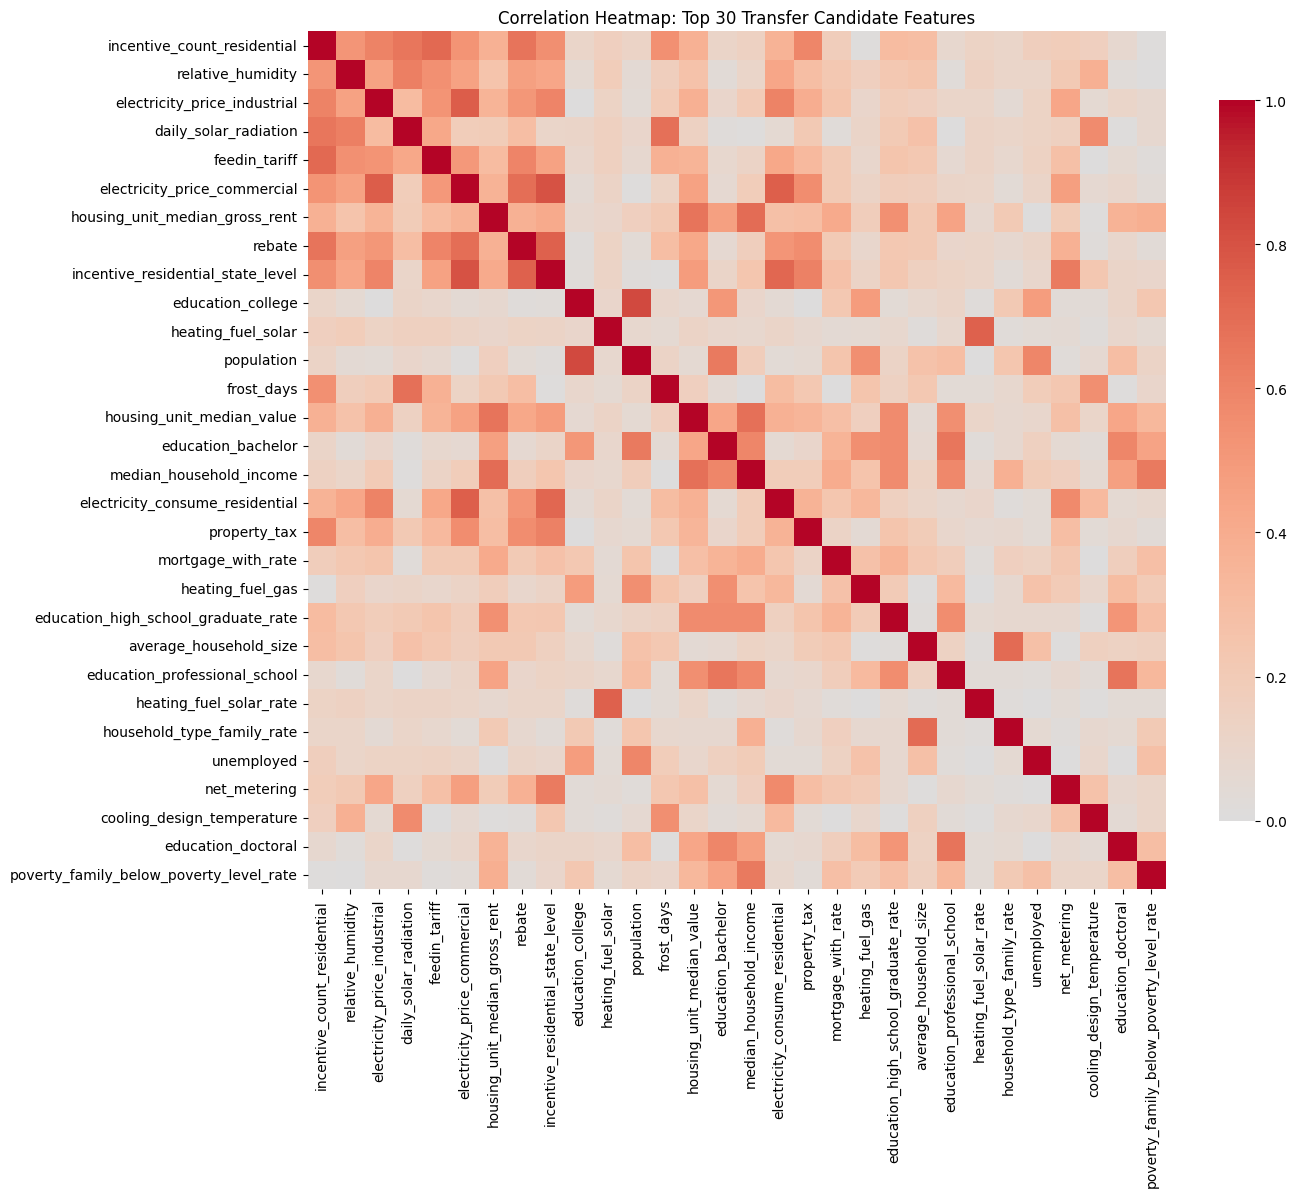

In [6]:
target_corr = df_clean[corr_selected + [target_col]].corr()[target_col].abs().sort_values(ascending=False)
top30 = target_corr.head(31).index.tolist()
if target_col in top30:
    top30.remove(target_col)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(df_clean[top30].corr().abs(), cmap='coolwarm', center=0,
            square=True, ax=ax, xticklabels=True, yticklabels=True,
            vmin=0, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap: Top 30 Transfer Candidate Features')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/02_correlation_heatmap_transfer.png', dpi=300, bbox_inches='tight')
plt.show()

## Save Tree / Transfer Feature Set (No VIF)

In [7]:
tree_features = corr_selected.copy()

corr_series_tree = df_clean[tree_features].corrwith(df_clean[target_col])
selected_tree = pd.DataFrame({'feature': tree_features})
selected_tree['target_corr'] = selected_tree['feature'].map(corr_series_tree)
selected_tree = selected_tree.sort_values('target_corr', key=lambda s: s.abs(), ascending=False)
selected_tree.to_csv(f'{RESULT_DIR}/selected_features_tree.csv', index=False)

modeling_tree = df_clean[tree_features + ['potential_label']].copy()
modeling_tree.to_csv(f'{DATA_DIR}/us_modeling_ready_tree.csv', index=False)

print(f'Tree feature count: {len(tree_features)}')
print(f'Saved to {RESULT_DIR}/selected_features_tree.csv')
print(f'Saved modeling dataset: {modeling_tree.shape}')
print(selected_tree.head(20))

Tree feature count: 102
Saved to ../outputs/results/transfer/selected_features_tree.csv
Saved modeling dataset: (72537, 103)
                               feature  target_corr
94         incentive_count_residential     0.361331
44                   relative_humidity    -0.353392
34        electricity_price_industrial     0.336128
45               daily_solar_radiation     0.324979
97                       feedin_tariff     0.321660
33        electricity_price_commercial     0.293980
40      housing_unit_median_gross_rent     0.290874
101                             rebate     0.280196
95   incentive_residential_state_level     0.269335
1                    education_college     0.246482
11                  heating_fuel_solar     0.245186
12                          population     0.235829
43                          frost_days    -0.230387
39           housing_unit_median_value     0.221682
0                   education_bachelor     0.216367
32             median_household_income     

## Filter Ranking & Embedded Feature Selection (Ch9)

依 MDS Ch9 四大方法補齊 embedded selection，並以投票法彙整：

1. **ANOVA F-test** (過濾法 §1)：分類目標下比 Pearson 更適合的排序指標，同時計算 Mutual Information
2. **Lasso** (嵌入法 §3)：L1 正則化對連續 `tile_count` 做回歸，係數被壓縮至 0 的特徵剔除
3. **ElasticNet** (嵌入法 §3)：L1+L2 結合，高共線性特徵群更穩健；`l1_ratio` 由 CV 自動選擇
4. **RF importance** (嵌入法 §3)：300 棵樹的平均不純度下降，取 >= 平均重要性的特徵
5. **Voting** (§4)：三種方法中 ≥2 方法選到 → `voted_features`（最終推薦特徵集）

Top 20 by ANOVA F-score (classification target):
                            feature  pearson_abs     anova_f  mutual_info
        incentive_count_residential     0.361331 9928.818887     0.179778
       electricity_price_industrial     0.336128 8519.240016     0.221315
                  relative_humidity     0.353392 7342.040557     0.210277
              daily_solar_radiation     0.324979 7103.171582     0.187877
  incentive_residential_state_level     0.269335 7045.565431     0.159959
     housing_unit_median_gross_rent     0.290874 6457.965840     0.100782
       electricity_price_commercial     0.293980 5906.221240     0.225224
                      feedin_tariff     0.321660 5434.653781     0.085298
                             rebate     0.280196 5325.214800     0.104836
          housing_unit_median_value     0.221682 4491.134712     0.099443
education_high_school_graduate_rate     0.164287 4040.594020     0.060376
                 education_bachelor     0.216367 3910.493952   

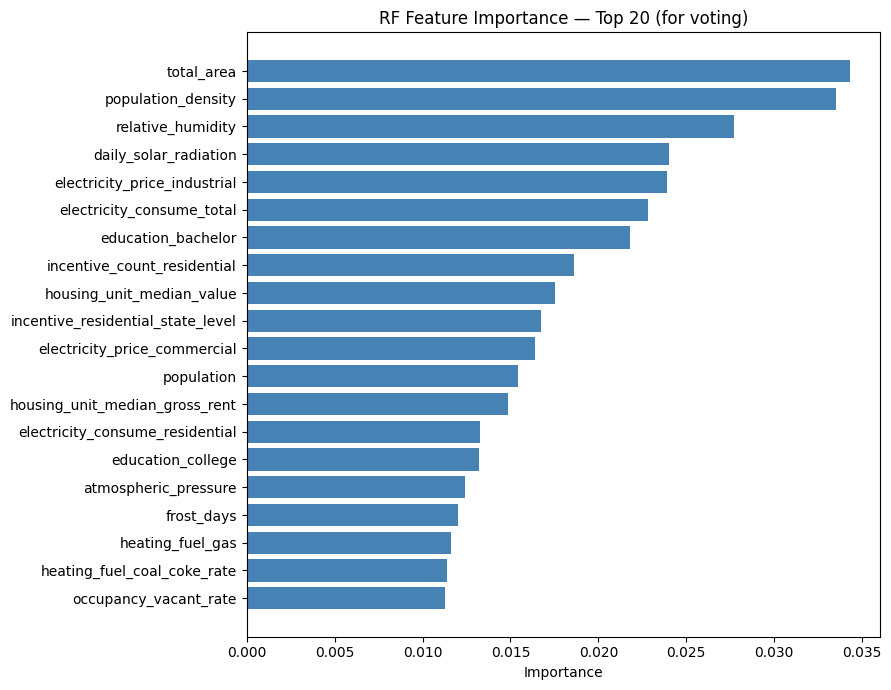


Voted features (>=2/3 methods): 90
Saved voted dataset: (72537, 91)
                          feature  lasso  enet   rf  vote_count
             atmospheric_pressure   True  True True           3
       cooling_design_temperature   True  True True           3
            daily_solar_radiation   True  True True           3
                education_college   True  True True           3
    education_professional_school   True  True True           3
  electricity_consume_residential   True  True True           3
        electricity_consume_total   True  True True           3
     electricity_price_commercial   True  True True           3
     electricity_price_industrial   True  True True           3
                       frost_days   True  True True           3
      heating_fuel_coal_coke_rate   True  True True           3
                 heating_fuel_gas   True  True True           3
   housing_unit_median_gross_rent   True  True True           3
        housing_unit_median_value  

In [8]:
# ─────────────────────────────────────────────────────────────────
# ANOVA F-test Filter Ranking (Ch9 §1)
# 對分類目標，ANOVA F-test 比 Pearson 更合適；同時計算 Mutual Information
# ─────────────────────────────────────────────────────────────────
from sklearn.feature_selection import f_classif, mutual_info_classif

X_feat = df_clean[corr_selected].values
y_clf  = df_clean['potential_label'].values
y_cont = df_clean[target_col].values

f_clf, _ = f_classif(X_feat, y_clf)
mi_clf   = mutual_info_classif(X_feat, y_clf, random_state=42)

filter_ranking = pd.DataFrame({
    'feature':     corr_selected,
    'pearson_abs': df_clean[corr_selected].corrwith(df_clean[target_col]).abs().values,
    'anova_f':     f_clf,
    'mutual_info': mi_clf,
}).sort_values('anova_f', ascending=False)
filter_ranking.to_csv(f'{RESULT_DIR}/filter_ranking.csv', index=False)
print('Top 20 by ANOVA F-score (classification target):')
print(filter_ranking.head(20).to_string(index=False))

# ─────────────────────────────────────────────────────────────────
# Embedded Selection: Lasso / ElasticNet (Ch9 §3)
# 對連續 tile_count 做 L1/L1+L2 正則化，壓縮係數至 0 的特徵被剔除
# ─────────────────────────────────────────────────────────────────
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler as _SS

_scaler = _SS()
X_s = _scaler.fit_transform(df_clean[corr_selected])

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000, n_jobs=-1)
lasso_cv.fit(X_s, y_cont)
lasso_selected = [f for f, c in zip(corr_selected, lasso_cv.coef_) if abs(c) > 1e-6]
print(f'LassoCV  alpha={lasso_cv.alpha_:.5f} → {len(lasso_selected)} features')

enet_cv = ElasticNetCV(cv=5, random_state=42, max_iter=10000,
                       l1_ratio=[0.5, 0.7, 0.9, 0.95, 1.0], n_jobs=-1)
enet_cv.fit(X_s, y_cont)
enet_selected = [f for f, c in zip(corr_selected, enet_cv.coef_) if abs(c) > 1e-6]
print(f'ElasticNet alpha={enet_cv.alpha_:.5f}, l1_ratio={enet_cv.l1_ratio_:.2f} → {len(enet_selected)} features')

# ─────────────────────────────────────────────────────────────────
# Embedded Selection: Random Forest Importance (Ch9 §3)
# ─────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier as _RFC

_rf = _RFC(n_estimators=300, random_state=42, n_jobs=-1)
_rf.fit(df_clean[corr_selected], df_clean['potential_label'])

rf_imp = pd.DataFrame({
    'feature':    corr_selected,
    'importance': _rf.feature_importances_,
}).sort_values('importance', ascending=False)

rf_threshold = rf_imp['importance'].mean()
rf_selected  = rf_imp[rf_imp['importance'] >= rf_threshold]['feature'].tolist()
print(f'\nRF importance (>= mean={rf_threshold:.5f}): {len(rf_selected)} features')

fig, ax = plt.subplots(figsize=(9, 7))
top20_rf = rf_imp.head(20).sort_values('importance')
ax.barh(top20_rf['feature'], top20_rf['importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('RF Feature Importance — Top 20 (for voting)')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/02_rf_importance_voting.png', dpi=300, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# Voting: Multi-Method Ensemble (Ch9 §4)
# 三種方法中至少 2 種選到 → voted_features
# ─────────────────────────────────────────────────────────────────
from collections import Counter

method_sets = {
    'lasso': set(lasso_selected),
    'enet':  set(enet_selected),
    'rf':    set(rf_selected),
}
vote_cnt = Counter()
for s in method_sets.values():
    for f in s:
        vote_cnt[f] += 1

voted_features = [f for f in corr_selected if vote_cnt[f] >= 2]
print(f'\nVoted features (>=2/3 methods): {len(voted_features)}')

vote_summary = pd.DataFrame({
    'feature':    corr_selected,
    'lasso':      [f in method_sets['lasso'] for f in corr_selected],
    'enet':       [f in method_sets['enet']  for f in corr_selected],
    'rf':         [f in method_sets['rf']    for f in corr_selected],
    'vote_count': [vote_cnt[f]               for f in corr_selected],
}).sort_values(['vote_count', 'feature'], ascending=[False, True])
vote_summary.to_csv(f'{RESULT_DIR}/voting_summary.csv', index=False)

modeling_voted = df_clean[voted_features + ['potential_label']].copy()
modeling_voted.to_csv(f'{DATA_DIR}/us_modeling_ready_voted.csv', index=False)
print(f'Saved voted dataset: {modeling_voted.shape}')
print(vote_summary.head(25).to_string(index=False))

In [9]:
# selected_features_voted.csv — 供 03_model_us_twostage.ipynb 以 FEATURE_SET='voted' 讀取
corr_series_voted = df_clean[voted_features].corrwith(df_clean[target_col])
selected_voted = pd.DataFrame({'feature': voted_features})
selected_voted['target_corr'] = selected_voted['feature'].map(corr_series_voted)
selected_voted = selected_voted.sort_values('target_corr', key=lambda s: s.abs(), ascending=False)
selected_voted.to_csv(f'{RESULT_DIR}/selected_features_voted.csv', index=False)
print(f'Voted feature count : {len(voted_features)}')
print(f'Saved to {RESULT_DIR}/selected_features_voted.csv')

Voted feature count : 90
Saved to ../outputs/results/transfer/selected_features_voted.csv


## VIF Screening for Interpretable Baseline

In [10]:
remaining = corr_selected.copy()
vif_threshold = 10
max_iter = 100

for i in range(max_iter):
    vif_df = compute_vif(df_clean, remaining)
    max_vif = vif_df['VIF'].max()
    if max_vif <= vif_threshold:
        break
    drop_col = vif_df.iloc[0]['feature']
    remaining.remove(drop_col)
    print(f'Iter {i+1}: dropped {drop_col} (VIF={max_vif:.1f}), remaining={len(remaining)}')
else:
    print('Reached max iterations')

print(f'Final VIF feature count: {len(remaining)}')

Iter 1: dropped atmospheric_pressure (VIF=4901.8), remaining=101
Iter 2: dropped transportation_car_alone_rate (VIF=2155.7), remaining=100
Iter 3: dropped heating_fuel_gas_rate (VIF=1976.0), remaining=99
Iter 4: dropped cooling_design_temperature (VIF=1222.1), remaining=98
Iter 5: dropped employ_rate (VIF=1170.0), remaining=97
Iter 6: dropped daily_solar_radiation (VIF=495.0), remaining=96
Iter 7: dropped age_median (VIF=466.7), remaining=95
Iter 8: dropped travel_time_10_19_rate (VIF=356.9), remaining=94
Iter 9: dropped relative_humidity (VIF=272.5), remaining=93
Iter 10: dropped population (VIF=249.8), remaining=92
Iter 11: dropped average_household_size (VIF=190.7), remaining=91
Iter 12: dropped electricity_price_commercial (VIF=152.8), remaining=90
Iter 13: dropped dropout_16_19_inschool_rate (VIF=132.9), remaining=89
Iter 14: dropped education_college_rate (VIF=128.9), remaining=88
Iter 15: dropped household_type_family_rate (VIF=107.8), remaining=87
Iter 16: dropped electricity_c

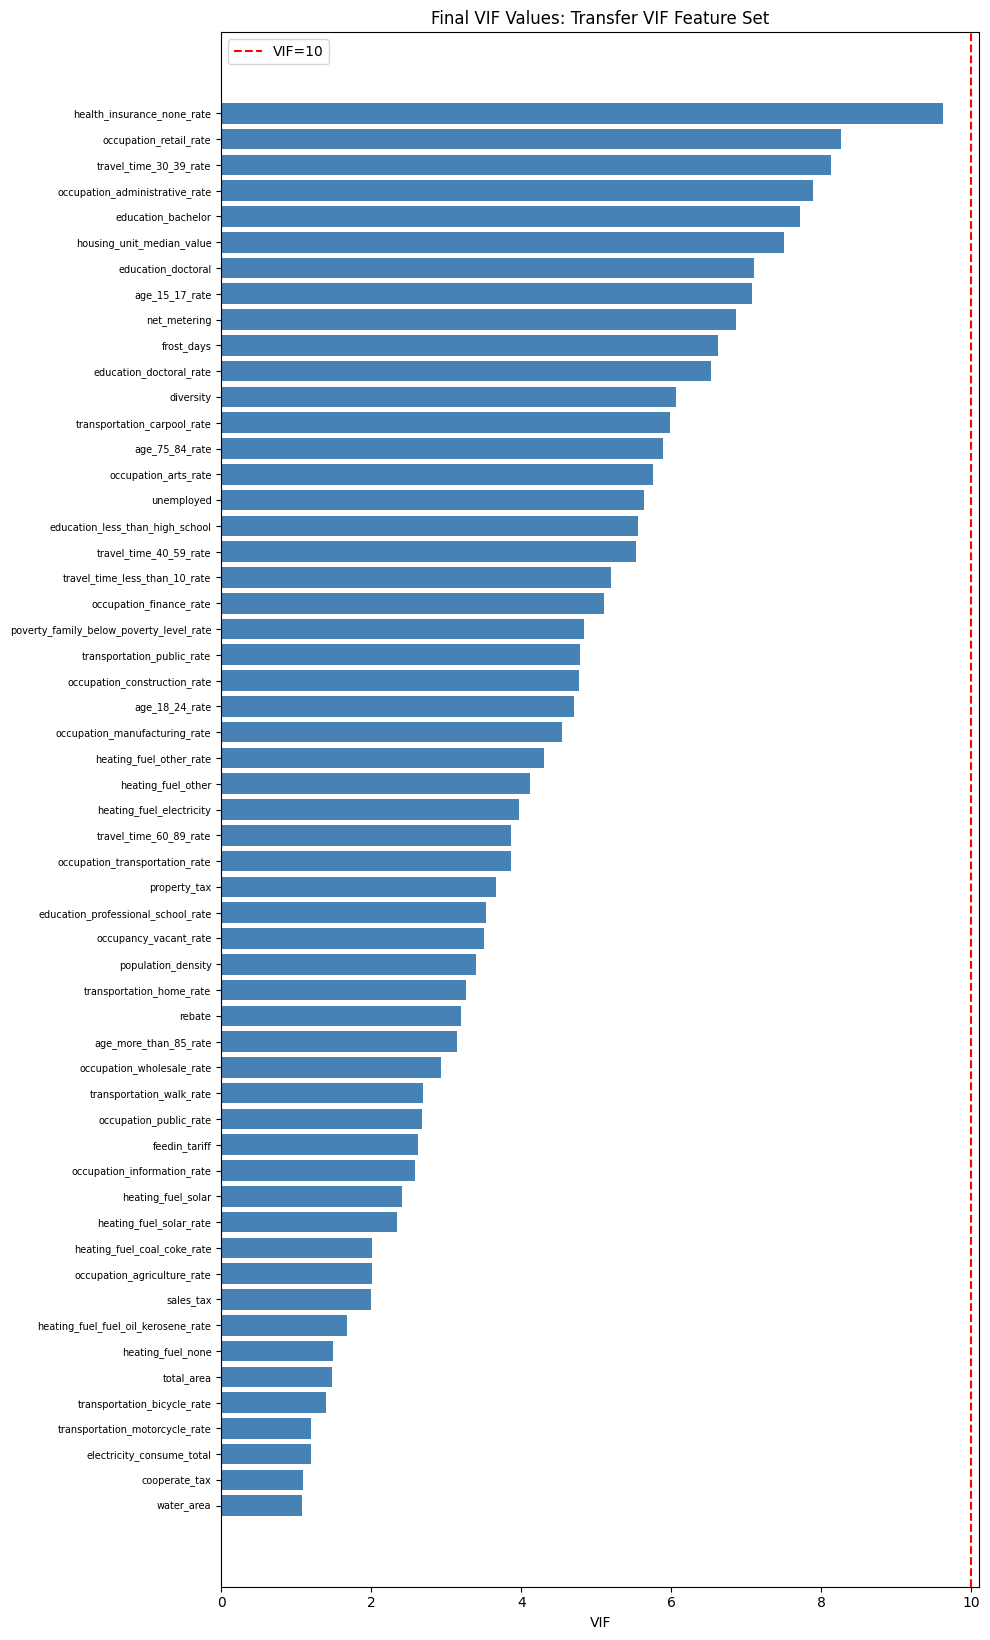

In [11]:
vif_final = compute_vif(df_clean, remaining)
fig, ax = plt.subplots(figsize=(10, max(6, len(vif_final) * 0.3)))
colors = ['coral' if v > 10 else 'steelblue' for v in vif_final['VIF']]
ax.barh(range(len(vif_final)), vif_final['VIF'], color=colors)
ax.set_yticks(range(len(vif_final)))
ax.set_yticklabels(vif_final['feature'], fontsize=7)
ax.invert_yaxis()
ax.axvline(10, color='red', linestyle='--', label='VIF=10')
ax.set_xlabel('VIF')
ax.set_title('Final VIF Values: Transfer VIF Feature Set')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/02_vif_final_transfer.png', dpi=300, bbox_inches='tight')
plt.show()

## Save VIF Feature Set

In [12]:
vif_features = remaining.copy()

corr_series_vif = df_clean[vif_features].corrwith(df_clean[target_col])
selected_vif = pd.DataFrame({'feature': vif_features})
selected_vif['target_corr'] = selected_vif['feature'].map(corr_series_vif)
selected_vif = selected_vif.sort_values('target_corr', key=lambda s: s.abs(), ascending=False)
selected_vif.to_csv(f'{RESULT_DIR}/selected_features_vif.csv', index=False)

modeling_vif = df_clean[vif_features + ['potential_label']].copy()
modeling_vif.to_csv(f'{DATA_DIR}/us_modeling_ready_vif.csv', index=False)

print(f'VIF feature count: {len(vif_features)}')
print(f'Saved to {RESULT_DIR}/selected_features_vif.csv')
print(f'Saved modeling dataset: {modeling_vif.shape}')
print(selected_vif.head(20))

VIF feature count: 55
Saved to ../outputs/results/transfer/selected_features_vif.csv
Saved modeling dataset: (72537, 56)
                                    feature  target_corr
50                            feedin_tariff     0.321660
54                                   rebate     0.280196
6                        heating_fuel_solar     0.245186
20                               frost_days    -0.230387
19                housing_unit_median_value     0.221682
0                        education_bachelor     0.216367
52                             property_tax     0.178510
16                  heating_fuel_solar_rate     0.152038
9                                unemployed     0.145929
49                             net_metering     0.138268
1                        education_doctoral     0.137368
13  poverty_family_below_poverty_level_rate    -0.121342
48                                diversity     0.104333
36                    occupancy_vacant_rate    -0.102371
37                 trans

## Save Transfer Metadata

In [13]:
metadata = {
    'profile': PROFILE,
    'target_col': target_col,
    'q33': float(q33),
    'q66': float(q66),
    'non_transferable_cols': [c for c in get_non_transferable_cols() if c in df.columns],
    'policy_concept_cols': [c for c in get_policy_concept_cols() if c in df.columns],
    'id_cols': [c for c in get_id_cols() if c in df.columns],
    'target_leakage_cols': [c for c in target_leakage if c in df.columns],
    'numeric_candidate_cols': numeric_cols,
    'corr_selected_features': corr_selected,
    'lasso_features': lasso_selected,
    'enet_features': enet_selected,
    'rf_features': rf_selected,
    'voted_features': voted_features,
    'tree_features': tree_features,
    'vif_features': vif_features,
}

with open(f'{DATA_DIR}/column_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f'Saved to {DATA_DIR}/column_metadata.json')
print(f'Feature set summary:')
print(f'  corr_selected : {len(corr_selected)}')
print(f'  lasso         : {len(lasso_selected)}')
print(f'  enet          : {len(enet_selected)}')
print(f'  rf            : {len(rf_selected)}')
print(f'  voted         : {len(voted_features)}')
print(f'  tree (corr)   : {len(tree_features)}')
print(f'  vif           : {len(vif_features)}')

Saved to ../data/processed/transfer/column_metadata.json
Feature set summary:
  corr_selected : 102
  lasso         : 87
  enet          : 99
  rf            : 29
  voted         : 90
  tree (corr)   : 102
  vif           : 55
